### Import required files

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

In [2]:
df = pd.read_csv("data\dataset_with_all_features.csv")

In [3]:
df.head()

,county,date,fire_label,max_frp,max_brightness,fire_count,temp_max,temp_min,humidity,wind_speed,...,temp_max_7d_rolling_mean,humidity_7d_rolling_mean,temp_max_14d_rolling_mean,humidity_14d_rolling_mean,temp_max_30d_rolling_mean,humidity_30d_rolling_mean,temperature_anomaly,vpd,wind_speed_drought_interaction,temp_max_humidity_interaction
0,Alameda,2010-01-01,0.0,0.0,0.0,0.0,13.2815,5.7315,84.409645,6.792466,...,13.281500,84.409645,13.281500,84.409645,13.281500,84.409645,0.000000,0.237843,0.000000,207.063300
1,Alameda,2010-01-02,0.0,0.0,0.0,0.0,13.4815,6.1815,95.559820,6.479999,...,13.381500,89.984733,13.381500,89.984733,13.381500,89.984733,0.100000,0.068628,0.000000,59.860287
2,Alameda,2010-01-03,0.0,0.0,0.0,0.0,12.9815,2.8315,84.136185,10.739832,...,13.248167,88.035217,13.248167,88.035217,13.248167,88.035217,-0.266667,0.237316,10.739832,205.936114
3,Alameda,2010-01-04,0.0,0.0,0.0,0.0,13.6315,2.5315,79.060646,7.244860,...,13.344000,85.791574,13.344000,85.791574,13.344000,85.791574,0.287500,0.326816,14.489720,285.434804
4,Alameda,2010-01-05,0.0,0.0,0.0,0.0,13.7315,4.6815,69.012860,7.100310,...,13.421500,82.435831,13.421500,82.435831,13.421500,82.435831,0.310000,0.486796,21.300930,425.499913


In [4]:
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values(["county", "date"]).reset_index(drop=True)

In [5]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Shape: (233044, 28)

Columns:
['county', 'date', 'fire_label', 'max_frp', 'max_brightness', 'fire_count', 'temp_max', 'temp_min', 'humidity', 'wind_speed', 'precipitation', 'month', 'month_sin', 'month_cos', 'day_of_year', 'weekend_flag', 'fire_season_flag', 'drought_index', 'temp_max_7d_rolling_mean', 'humidity_7d_rolling_mean', 'temp_max_14d_rolling_mean', 'humidity_14d_rolling_mean', 'temp_max_30d_rolling_mean', 'humidity_30d_rolling_mean', 'temperature_anomaly', 'vpd', 'wind_speed_drought_interaction', 'temp_max_humidity_interaction']


In [6]:
print("\nData types:")
print(df.dtypes)


Data types:
county                                    object
date                              datetime64[ns]
fire_label                               float64
max_frp                                  float64
max_brightness                           float64
fire_count                               float64
temp_max                                 float64
temp_min                                 float64
humidity                                 float64
wind_speed                               float64
precipitation                            float64
month                                      int64
month_sin                                float64
month_cos                                float64
day_of_year                                int64
weekend_flag                               int64
fire_season_flag                           int64
drought_index                              int64
temp_max_7d_rolling_mean                 float64
humidity_7d_rolling_mean                 float64
temp_ma

### Basic Summary

In [7]:
print("\nMissing values:")
display(df.isnull().sum().sort_values(ascending=False))


Missing values:


county                            0
date                              0
wind_speed_drought_interaction    0
vpd                               0
temperature_anomaly               0
humidity_30d_rolling_mean         0
temp_max_30d_rolling_mean         0
humidity_14d_rolling_mean         0
temp_max_14d_rolling_mean         0
humidity_7d_rolling_mean          0
temp_max_7d_rolling_mean          0
drought_index                     0
fire_season_flag                  0
weekend_flag                      0
day_of_year                       0
month_cos                         0
month_sin                         0
month                             0
precipitation                     0
wind_speed                        0
humidity                          0
temp_min                          0
temp_max                          0
fire_count                        0
max_brightness                    0
max_frp                           0
fire_label                        0
temp_max_humidity_interactio

In [8]:
print("\nSummary statistics:")
display(df.describe(include="all").T)


Summary statistics:


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
county,233044,58,Alameda,4018,NaN,NaN,NaN,NaN,NaN,NaN,NaN
date,233044,NaN,NaN,NaN,2015-07-02 12:00:00.000000512,2010-01-01 00:00:00,2012-10-01 00:00:00,2015-07-02 12:00:00,2018-04-02 00:00:00,2020-12-31 00:00:00,NaN
fire_label,233044.0,NaN,NaN,NaN,0.020781,0.0,0.0,0.0,0.0,1.0,0.142652
max_frp,233044.0,NaN,NaN,NaN,7.538244,0.0,0.0,0.0,0.0,11233.2,128.938199
max_brightness,233044.0,NaN,NaN,NaN,7.543393,0.0,0.0,0.0,0.0,507.0,52.170105
fire_count,233044.0,NaN,NaN,NaN,0.256102,0.0,0.0,0.0,0.0,458.0,4.641671
temp_max,233044.0,NaN,NaN,NaN,20.507989,-14.6045,13.7,19.9605,27.6175,50.835003,9.585896
temp_min,233044.0,NaN,NaN,NaN,8.781217,-25.431002,4.159,8.95175,13.537,34.285,7.324521
humidity,233044.0,NaN,NaN,NaN,54.285612,3.889559,36.705924,54.418823,71.34125,114.50146,21.424422
wind_speed,233044.0,NaN,NaN,NaN,14.1097,2.305125,10.182337,13.004922,16.704155,79.03374,5.701136


- The dataset contains 233K records across 58 counties (2010–2020), providing strong temporal and geographic coverage for modeling wildfire risk.
- The target variable is highly imbalanced (~2% fire days), indicating the need for techniques like SMOTE or class weighting.
- Fire-related features are heavily skewed with many zeros and extreme spikes, showing that fire events are rare but occasionally very intense.
- Weather and engineered features (e.g., temperature, drought index, VPD) show wide variability and realistic ranges, suggesting they are informative predictors of wildfire occurrence.

### Class Distribution

In [9]:
class_counts = df["fire_label"].value_counts().sort_index()
class_pct = df["fire_label"].value_counts(normalize=True).sort_index() * 100

In [10]:
print("Class counts:")
print(class_counts)

Class counts:
fire_label
0.0    228201
1.0      4843
Name: count, dtype: int64


In [11]:
print("\nClass percentages:")
print(class_pct.round(2))


Class percentages:
fire_label
0.0    97.92
1.0     2.08
Name: proportion, dtype: float64


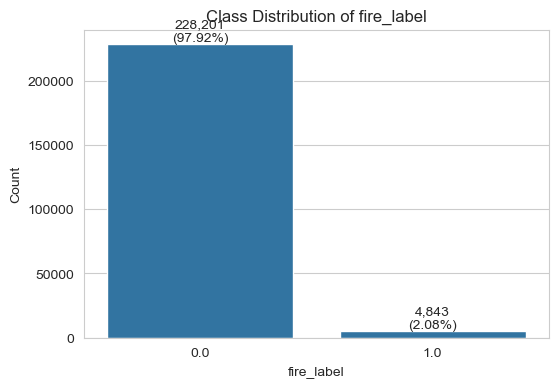

In [12]:
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=df, x="fire_label")
plt.title("Class Distribution of fire_label")
plt.xlabel("fire_label")
plt.ylabel("Count")

for i, v in enumerate(class_counts.values):
    plt.text(i, v + max(class_counts) * 0.01, f"{v:,}\n({class_pct.iloc[i]:.2f}%)",
             ha="center", fontsize=10)

plt.show()

- The dataset is highly imbalanced, with ~97.9% non-fire days (0) and only ~2.1% fire days (1).
- This confirms that wildfire events are rare, making classification more challenging due to limited positive examples.
- The imbalance justifies the use of SMOTE or class weighting techniques during model training.
- Without handling this imbalance, models may become biased toward predicting the majority class (no fire).

### Monthly fire frequency

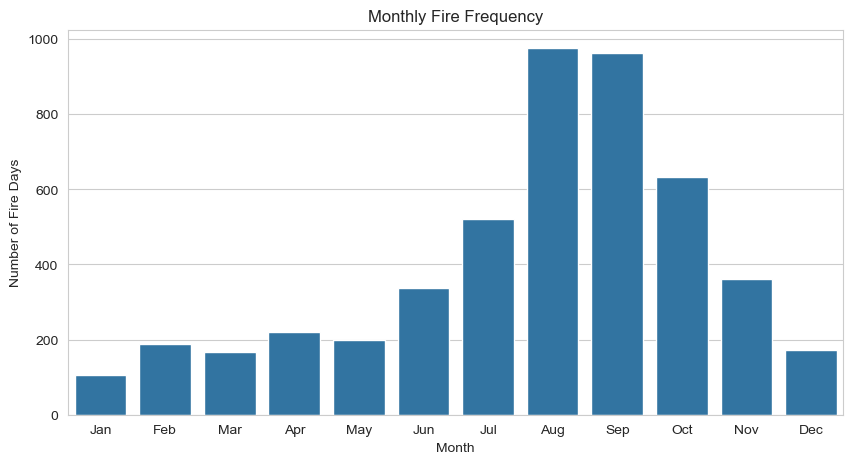

Monthly fire counts:


month
1     106
2     187
3     168
4     221
5     198
6     337
7     520
8     976
9     963
10    633
11    361
12    173
dtype: int64

In [13]:
monthly_fires = df[df["fire_label"] == 1].groupby("month").size().reindex(range(1, 13), fill_value=0)

plt.figure(figsize=(10, 5))
sns.barplot(x=monthly_fires.index, y=monthly_fires.values)
plt.title("Monthly Fire Frequency")
plt.xlabel("Month")
plt.ylabel("Number of Fire Days")
plt.xticks(range(0, 12), labels=[
    "Jan","Feb","Mar","Apr","May","Jun",
    "Jul","Aug","Sep","Oct","Nov","Dec"
])
plt.show()

print("Monthly fire counts:")
display(monthly_fires)

- Fire activity shows a strong seasonal pattern, increasing sharply from June and peaking in August and September.
- The highest number of fire days occurs in late summer, with August (976) and September (963) being the most active months.
- Fire frequency declines significantly after October, with winter months (Dec–Feb) having very low activity.
- This pattern aligns with California’s dry season, indicating that seasonal features are important predictors of wildfire risk.

### Yearly trend (2010-2020)

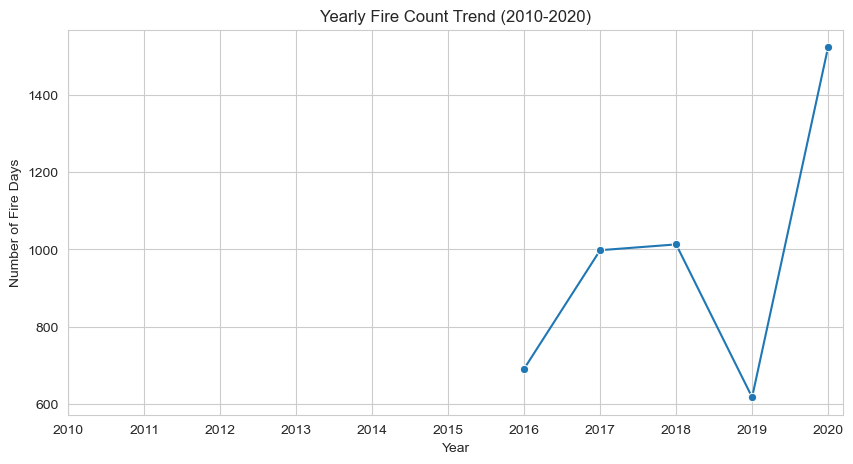

Yearly fire counts:


year
2016     691
2017     998
2018    1013
2019     617
2020    1524
dtype: int64

In [14]:
df["year"] = df["date"].dt.year
yearly_fires = df[df["fire_label"] == 1].groupby("year").size()

plt.figure(figsize=(10, 5))
sns.lineplot(x=yearly_fires.index, y=yearly_fires.values, marker="o")
plt.title("Yearly Fire Count Trend (2010-2020)")
plt.xlabel("Year")
plt.ylabel("Number of Fire Days")
plt.xticks(sorted(df["year"].unique()))
plt.show()

print("Yearly fire counts:")
display(yearly_fires)

- Fire activity shows significant variation across years, indicating that wildfire occurrence is not consistent over time.
- There is an increasing trend from 2016 to 2018, suggesting worsening fire conditions during that period.
- A noticeable drop in 2019 is followed by a sharp spike in 2020 (~1524 fires), the highest in the dataset.
- This variability suggests that external factors like climate and drought conditions strongly influence yearly fire risk.

### Top 15 counties by fire days

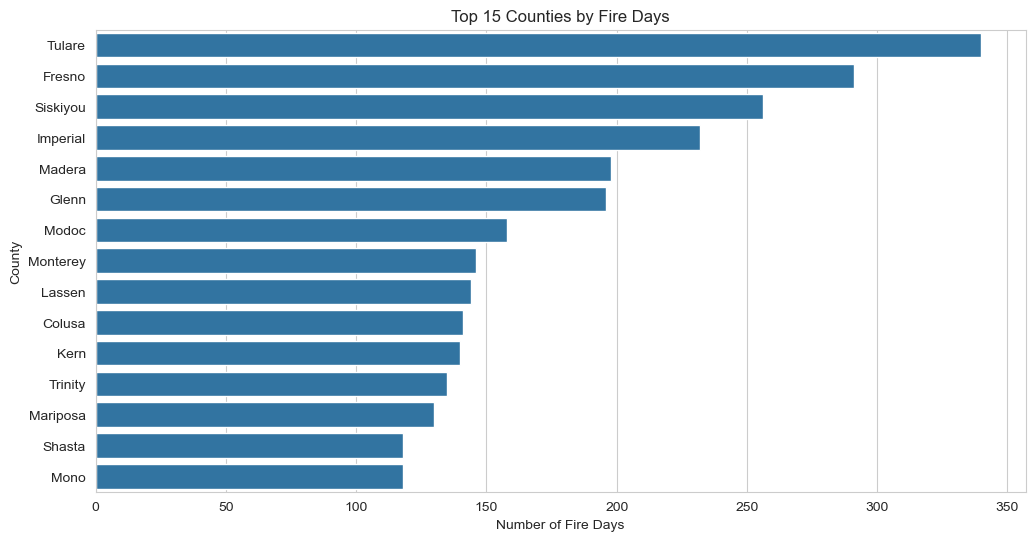

county
Tulare      340
Fresno      291
Siskiyou    256
Imperial    232
Madera      198
Glenn       196
Modoc       158
Monterey    146
Lassen      144
Colusa      141
Kern        140
Trinity     135
Mariposa    130
Shasta      118
Mono        118
dtype: int64

In [15]:
top_counties = (
    df[df["fire_label"] == 1]
    .groupby("county")
    .size()
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_counties.values, y=top_counties.index)
plt.title("Top 15 Counties by Fire Days")
plt.xlabel("Number of Fire Days")
plt.ylabel("County")
plt.show()

display(top_counties)


- Wildfire activity is unevenly distributed across counties, with a small number accounting for a large share of fire days.
- Tulare (~ 340) and Fresno (~ 291) have the highest fire counts, indicating they are major wildfire-prone regions.
- Several inland and northern counties (e.g., Siskiyou, Imperial, Madera) also show consistently high fire activity.
- This geographic concentration suggests that location (county) is an important feature for predicting wildfire risk.

### Missing values percentage

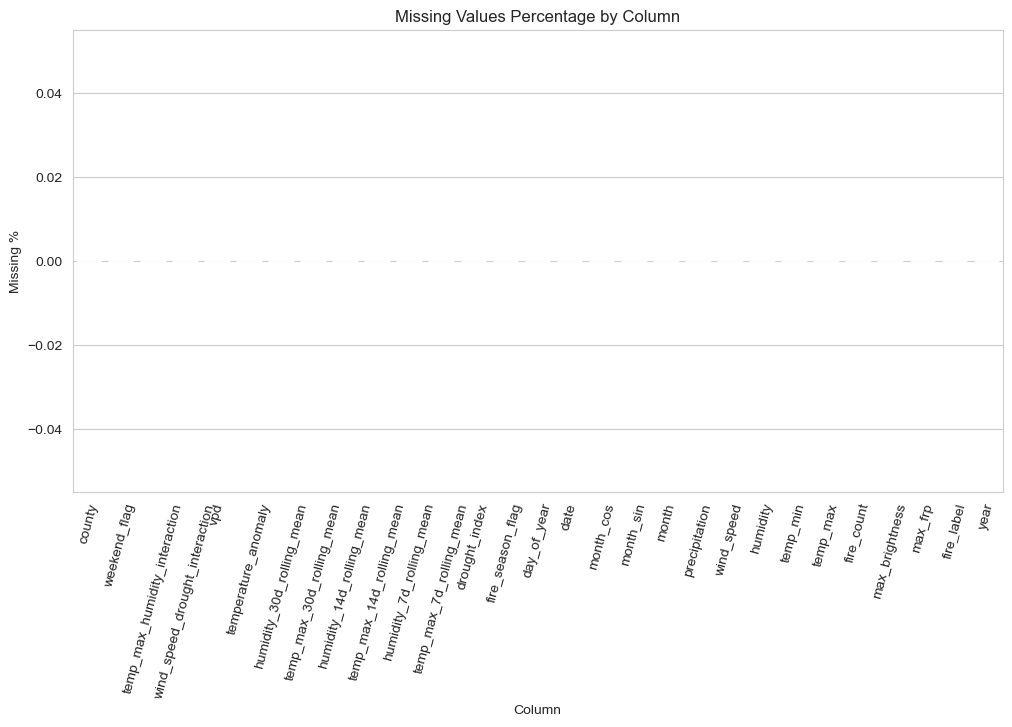

county                            0.0
weekend_flag                      0.0
temp_max_humidity_interaction     0.0
wind_speed_drought_interaction    0.0
vpd                               0.0
temperature_anomaly               0.0
humidity_30d_rolling_mean         0.0
temp_max_30d_rolling_mean         0.0
humidity_14d_rolling_mean         0.0
temp_max_14d_rolling_mean         0.0
humidity_7d_rolling_mean          0.0
temp_max_7d_rolling_mean          0.0
drought_index                     0.0
fire_season_flag                  0.0
day_of_year                       0.0
date                              0.0
month_cos                         0.0
month_sin                         0.0
month                             0.0
precipitation                     0.0
wind_speed                        0.0
humidity                          0.0
temp_min                          0.0
temp_max                          0.0
fire_count                        0.0
max_brightness                    0.0
max_frp     

In [16]:
missing_pct = (df.isnull().mean() * 100).sort_values(ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x=missing_pct.index, y=missing_pct.values)
plt.title("Missing Values Percentage by Column")
plt.xlabel("Column")
plt.ylabel("Missing %")
plt.xticks(rotation=75)
plt.show()

display(missing_pct)

- There are no null values

### Correlation heatmap

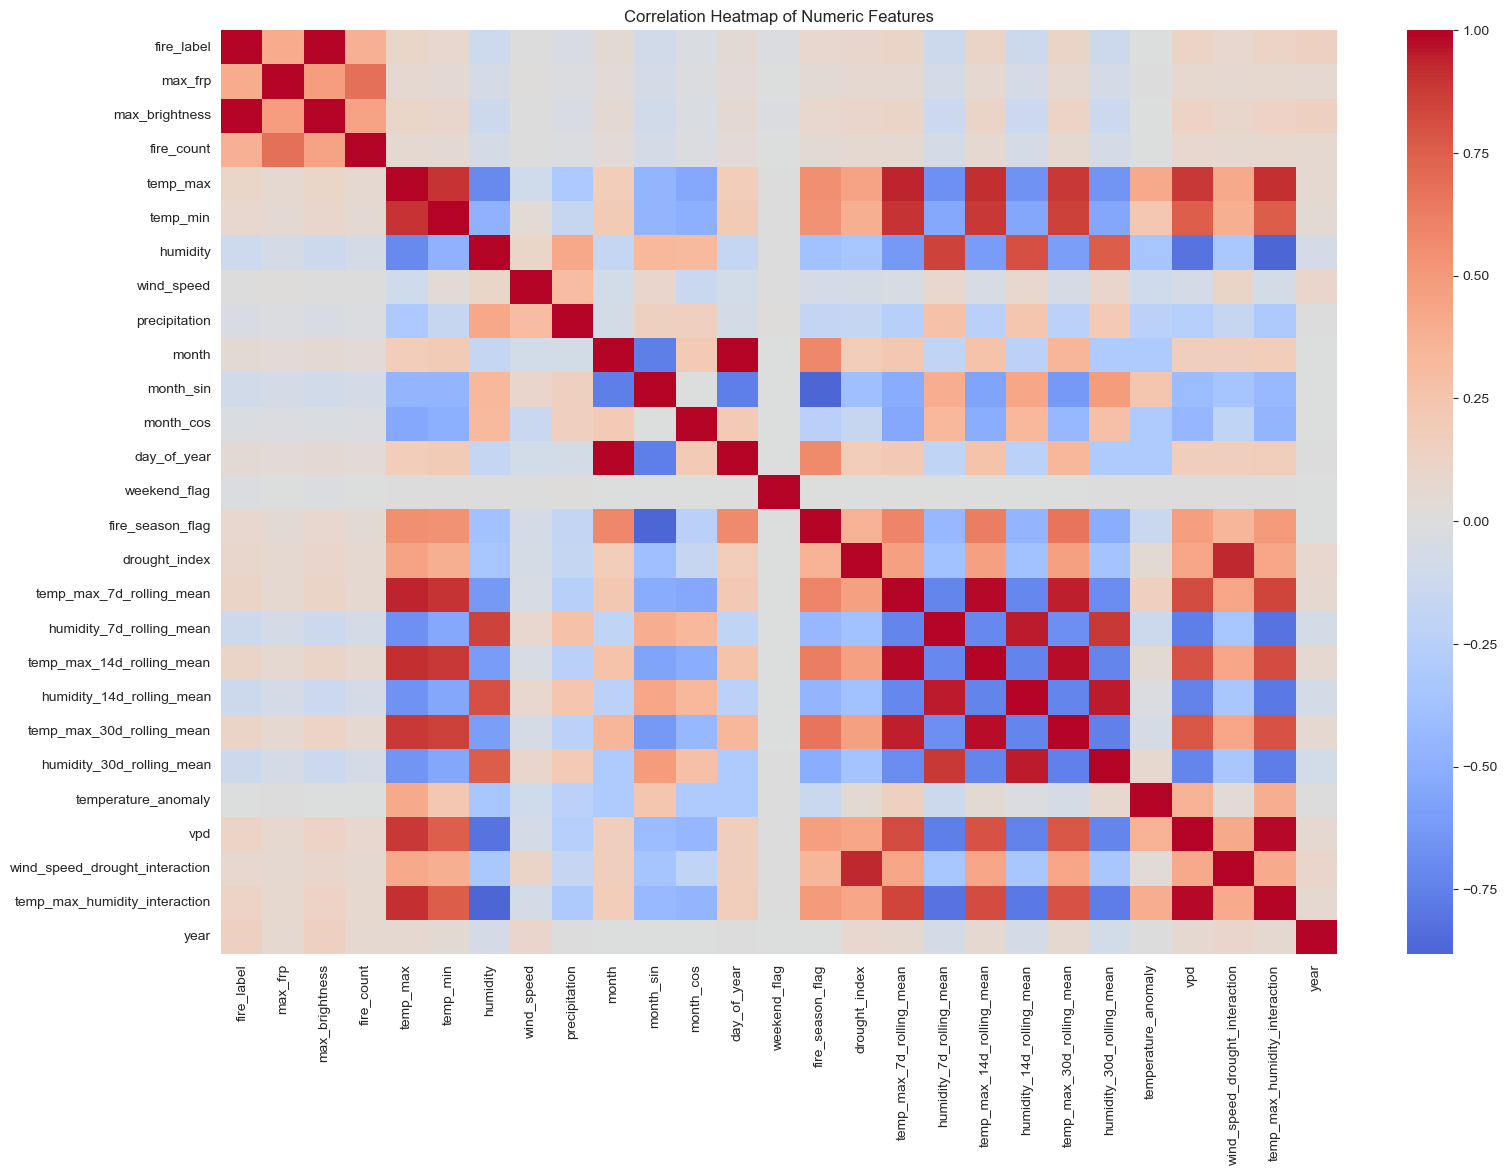

Correlation with fire_label:


fire_label                        1.000000
max_brightness                    0.992539
max_frp                           0.401320
fire_count                        0.378740
year                              0.150383
temp_max_humidity_interaction     0.124660
vpd                               0.121006
temp_max_30d_rolling_mean         0.115937
temp_max_14d_rolling_mean         0.113513
temp_max_7d_rolling_mean          0.111140
temp_max                          0.105303
drought_index                     0.094014
temp_min                          0.087425
wind_speed_drought_interaction    0.086791
fire_season_flag                  0.082040
month                             0.050438
day_of_year                       0.050419
wind_speed                        0.001596
temperature_anomaly              -0.001023
weekend_flag                     -0.019091
month_cos                        -0.023787
precipitation                    -0.035894
month_sin                        -0.089533
humidity   

In [17]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

corr = df[numeric_cols].corr()

plt.figure(figsize=(18, 12))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=False)
plt.title("Correlation Heatmap of Numeric Features")
plt.show()

# Correlation with target
fire_corr = corr["fire_label"].sort_values(ascending=False)
print("Correlation with fire_label:")
display(fire_corr)

- Fire-related variables (max_brightness, max_frp, fire_count) show very strong correlation with fire_label, but these are likely data leakage features and should not be used for prediction.
- Temperature-related features (e.g., temp_max, rolling means, and interaction terms) show positive correlation with fire occurrence, indicating higher temperatures increase fire risk.
- Humidity features show negative correlation with fire_label, meaning lower humidity is associated with higher fire likelihood.
- Engineered features like vpd, drought_index, and interaction terms show moderate correlation, suggesting they capture important environmental conditions influencing wildfires.

### Histograms by fire_label

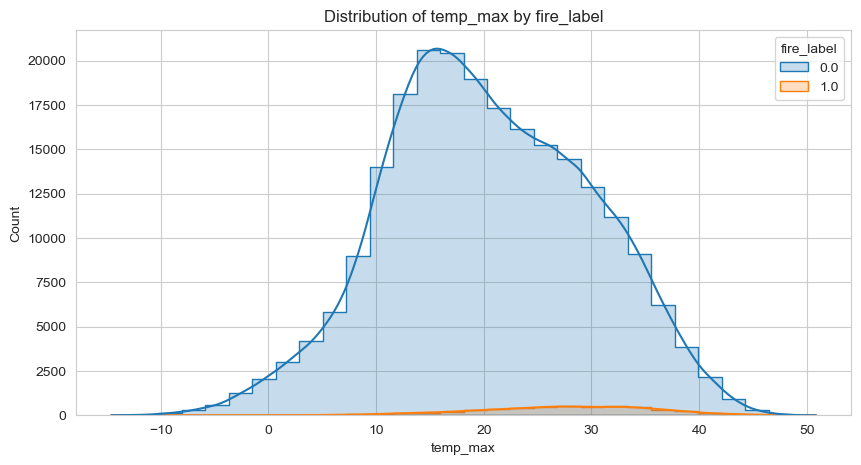

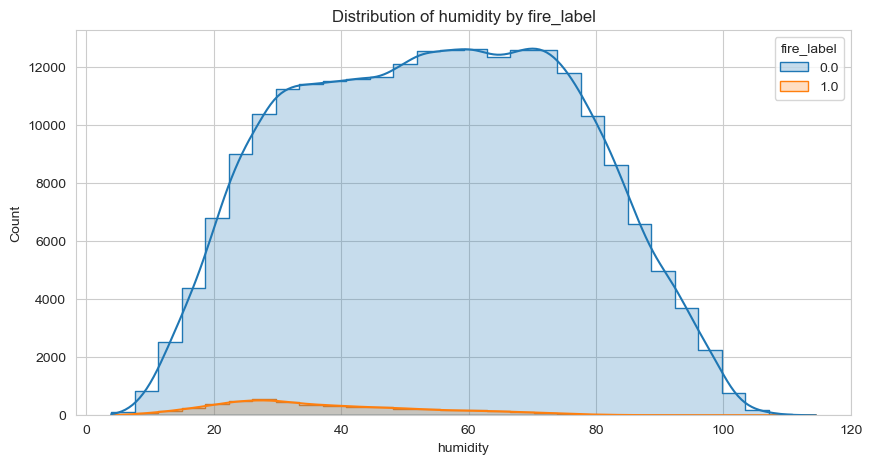

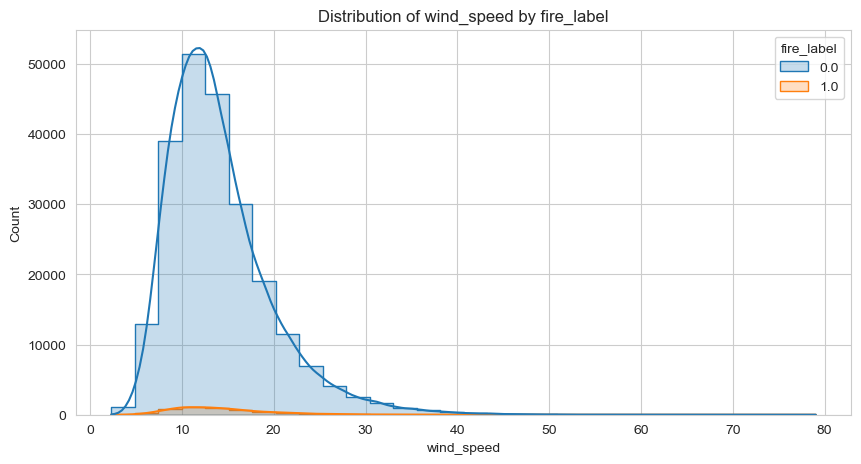

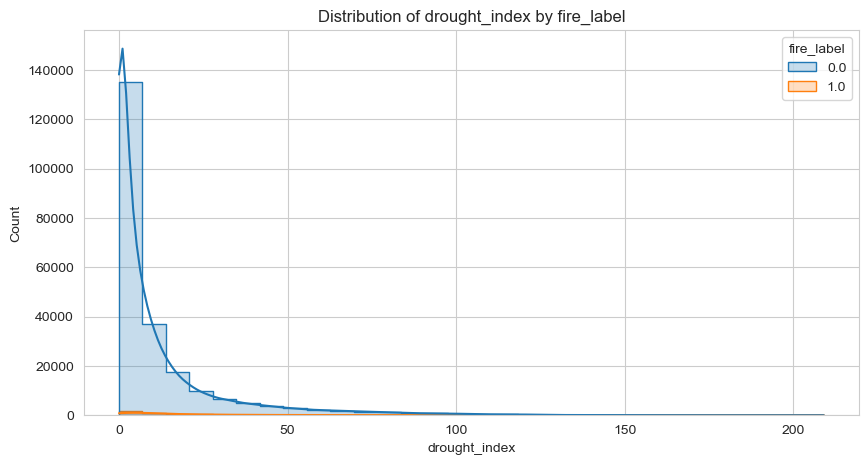

In [18]:
features_for_hist = ["temp_max", "humidity", "wind_speed", "drought_index"]

for col in features_for_hist:
    plt.figure(figsize=(10, 5))
    sns.histplot(data=df, x=col, hue="fire_label", kde=True, bins=30, element="step")
    plt.title(f"Distribution of {col} by fire_label")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

- Fire days (label = 1) tend to occur at higher temperatures, with the distribution shifted toward warmer values compared to non-fire days.
- Fire events are associated with lower humidity levels, indicating that drier conditions increase wildfire likelihood.
- Wind speed shows a slight increase during fire days, suggesting it may contribute to fire spread, though the separation is less pronounced.
- The drought_index is higher for fire days, confirming that prolonged dry conditions significantly increase wildfire risk.

### Box plots by fire_label

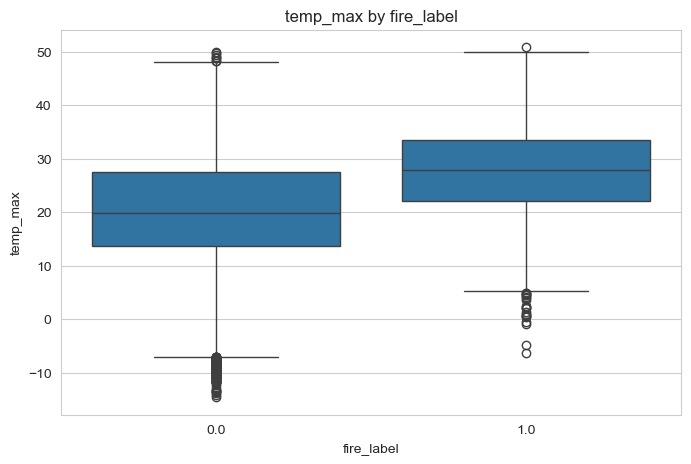

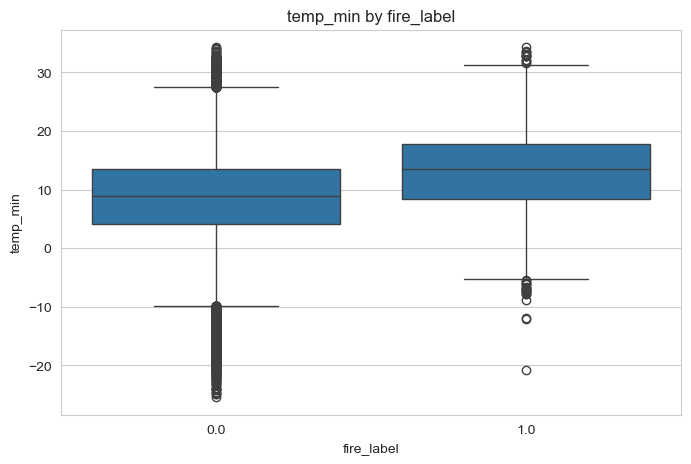

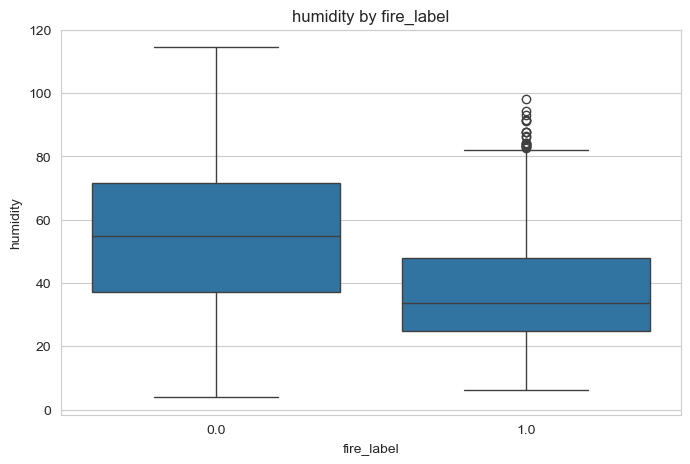

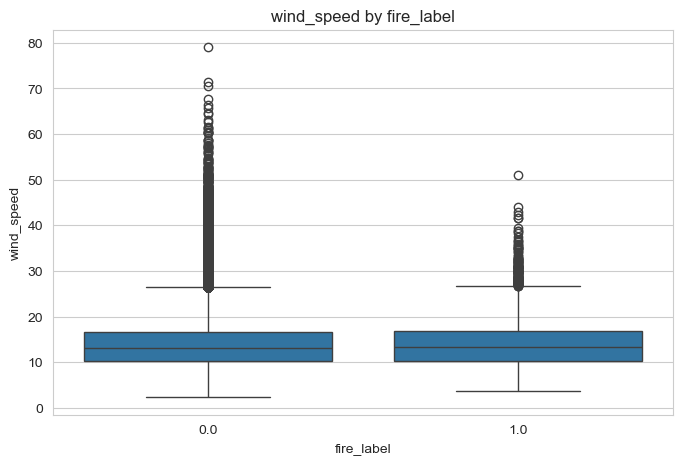

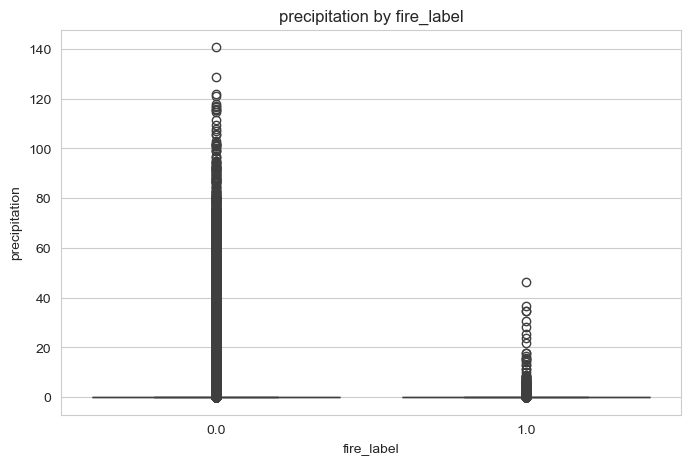

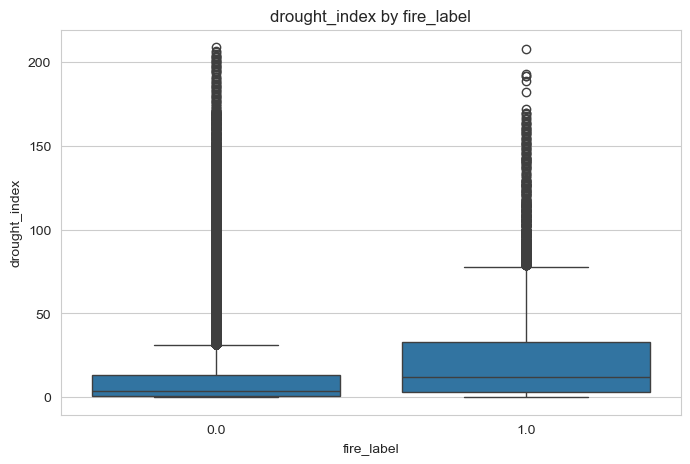

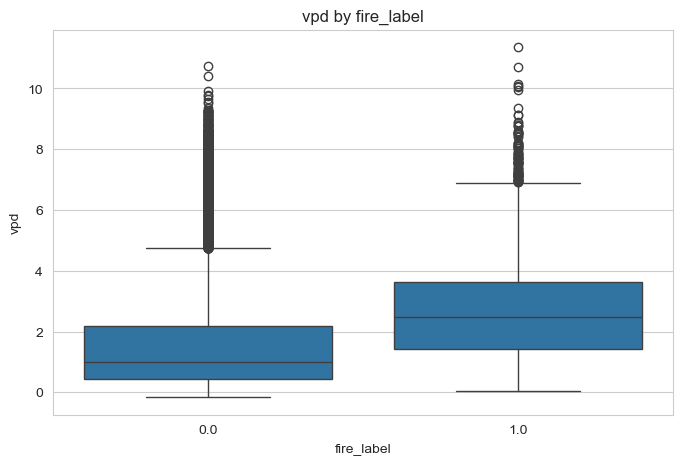

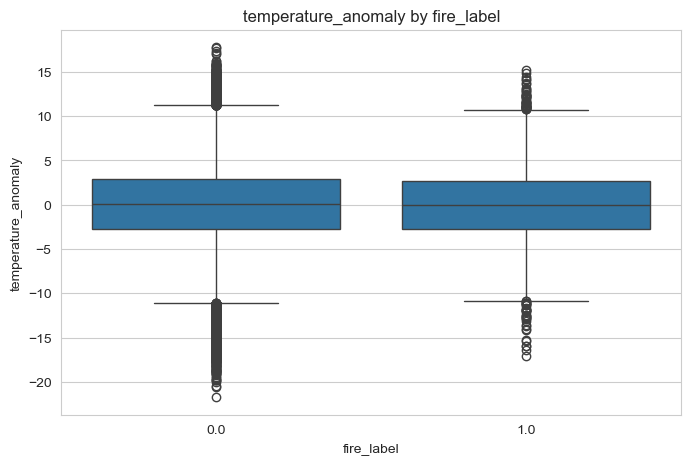

In [19]:
box_features = [
    "temp_max", "temp_min", "humidity", "wind_speed",
    "precipitation", "drought_index", "vpd", "temperature_anomaly"
]

for col in box_features:
    plt.figure(figsize=(8, 5))
    sns.boxplot(data=df, x="fire_label", y=col)
    plt.title(f"{col} by fire_label")
    plt.xlabel("fire_label")
    plt.ylabel(col)
    plt.show()

- **Max Temperature (temp_max):** Fire days have a noticeably higher median temperature, indicating that hotter conditions strongly increase wildfire likelihood.
- **Min Temperature (temp_min):** Fire days also show higher nighttime temperatures, suggesting that sustained heat (not just daytime peaks) contributes to fire risk.
- **Humidity:** Fire days have a significantly lower median humidity, confirming that drier air is a key factor in wildfire occurrence.
- **Wind Speed:** Wind speed is slightly higher for fire days, but with substantial overlap, indicating it plays a role but is less dominant compared to temperature and humidity.
- **Precipitation:** Both groups have a median near zero, but fire days show very low precipitation overall, reinforcing that fires occur during dry periods.
- **Drought Index:** Fire days have a higher median and wider spread, showing that longer dry spells significantly increase fire risk.
- **VPD (Vapor Pressure Deficit):** Fire days have higher VPD values, indicating drier atmospheric conditions that promote wildfire ignition and spread.
- **Temperature Anomaly:** Fire days tend to have slightly higher anomalies, suggesting that unusually hot conditions relative to recent trends may contribute to fire occurrence.

### Fire season flag vs target

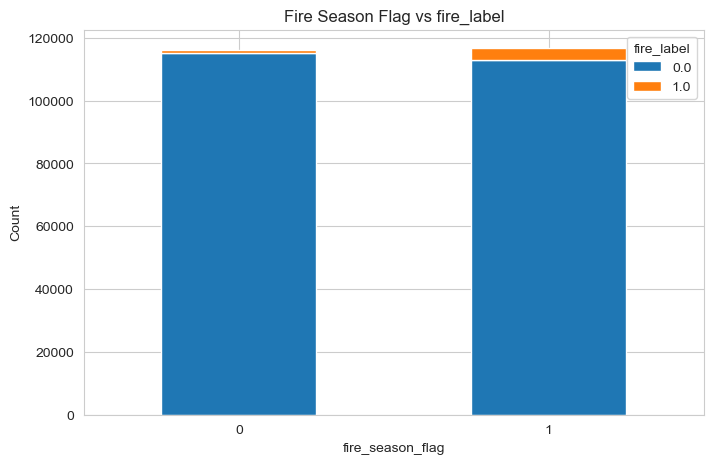

fire_label,0.0,1.0
fire_season_flag,,
0,115237,1053
1,112964,3790


In [20]:
season_counts = pd.crosstab(df["fire_season_flag"], df["fire_label"])

season_counts.plot(kind="bar", stacked=True, figsize=(8, 5))
plt.title("Fire Season Flag vs fire_label")
plt.xlabel("fire_season_flag")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

display(season_counts)

- Fire occurrences are significantly higher during fire season (flag = 1) compared to non-fire season.
- Although total days are similar in both groups, fire days are much more concentrated in the fire season (3790 vs 1053).
- This shows that the fire_season_flag is a strong and meaningful predictor of wildfire risk.
- The result aligns with earlier monthly analysis, confirming that seasonality plays a critical role in wildfire occurrence.

### Weekend flag vs target

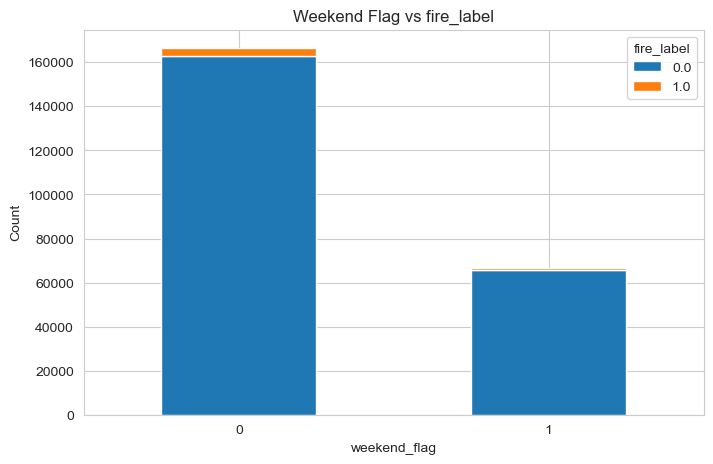

fire_label,0.0,1.0
weekend_flag,,
0,162714,3746
1,65487,1097


In [21]:
weekend_counts = pd.crosstab(df["weekend_flag"], df["fire_label"])

weekend_counts.plot(kind="bar", stacked=True, figsize=(8, 5))
plt.title("Weekend Flag vs fire_label")
plt.xlabel("weekend_flag")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

display(weekend_counts)

- Fire occurrences are slightly more frequent on weekdays (flag = 0) than weekends, but the difference is not large.
- The distribution of fire and non-fire days is similar across weekdays and weekends, indicating limited impact of this feature.
- This suggests that wildfire occurrence is primarily driven by environmental factors rather than human activity patterns tied to weekends.
- Overall, weekend_flag appears to be a weak predictor compared to features like temperature, drought, and seasonality.

### Scatter plots of key relationships

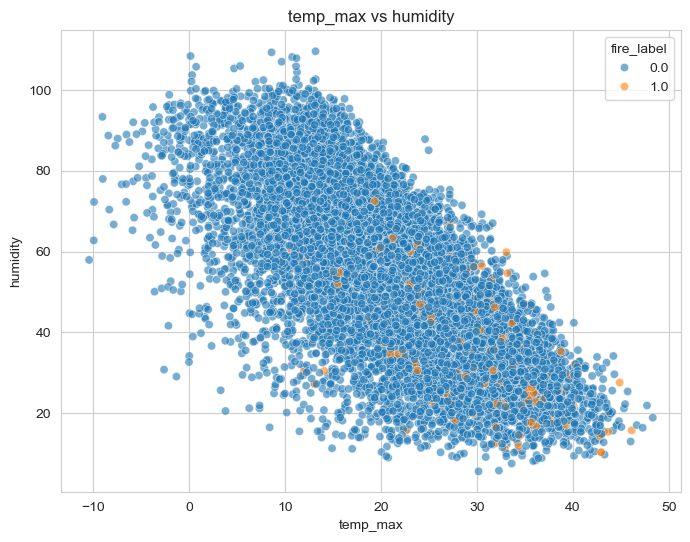

In [22]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df.sample(min(10000, len(df)), random_state=42),
                x="temp_max", y="humidity", hue="fire_label", alpha=0.6)
plt.title("temp_max vs humidity")
plt.show()

- There is a clear negative relationship between temperature and humidity, with higher temperatures associated with lower humidity levels.
- Fire days (orange points) are concentrated in regions with high temperature and low humidity, highlighting favorable conditions for wildfire occurrence.
- Non-fire days are spread across all conditions, but fire events occur mostly in hot and dry regions of the feature space.
- This pattern reinforces that the combination of high temperature and low humidity is a strong indicator of wildfire risk, not just each feature individually.

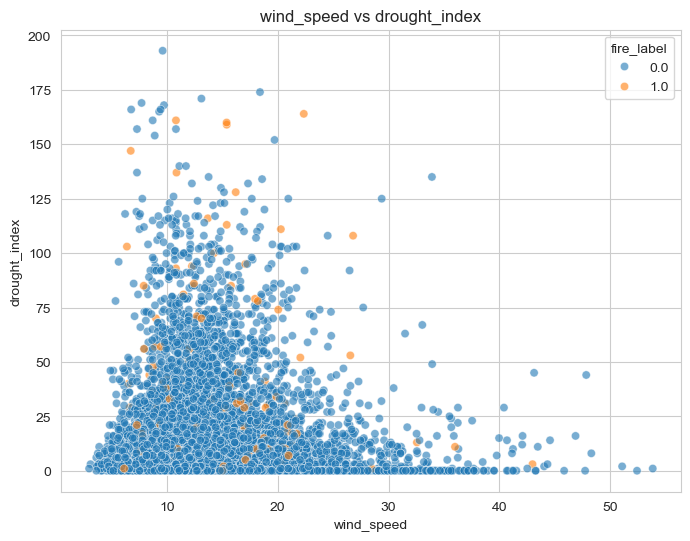

In [23]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df.sample(min(10000, len(df)), random_state=42),
                x="wind_speed", y="drought_index", hue="fire_label", alpha=0.6)
plt.title("wind_speed vs drought_index")
plt.show()

- There is no strong linear relationship between wind speed and drought index, as points are widely scattered.
- Fire days (orange points) tend to appear more frequently at higher drought index values, reinforcing the importance of prolonged dry conditions.
- Wind speed shows some spread during fire events, but does not clearly separate fire vs non-fire cases on its own.
- This suggests that drought conditions are more influential than wind speed individually, though their interaction may still be important for modeling.

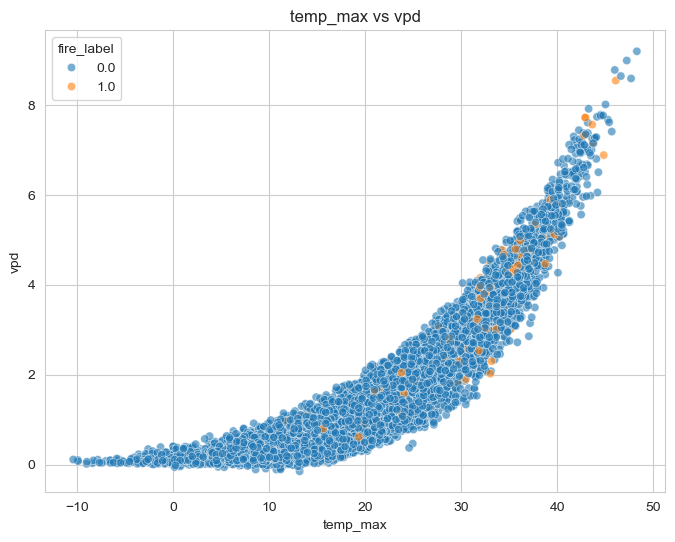

In [24]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df.sample(min(10000, len(df)), random_state=42),
                x="temp_max", y="vpd", hue="fire_label", alpha=0.6)
plt.title("temp_max vs vpd")
plt.show()

- There is a strong positive nonlinear relationship between temperature and VPD, with VPD increasing rapidly at higher temperatures.
- Fire days (orange points) are concentrated in regions with both high temperature and high VPD, indicating very dry atmospheric conditions.
- The upward curve shows that small increases in temperature at higher ranges lead to large increases in dryness (VPD).
- This confirms that VPD is a powerful feature, capturing combined effects of temperature and humidity on wildfire risk.

### Rolling weather features vs fire_label

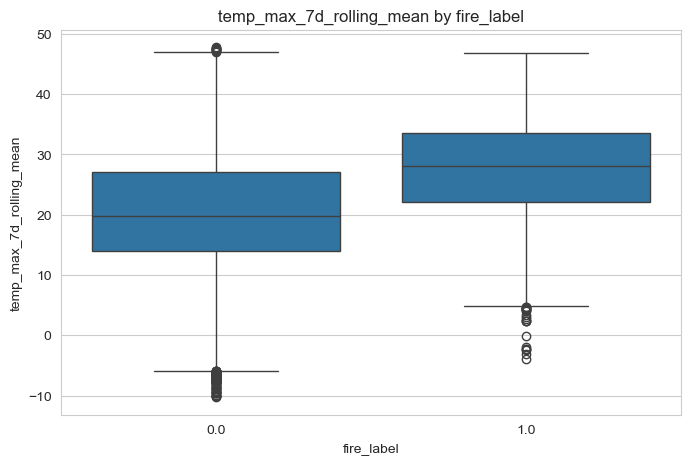

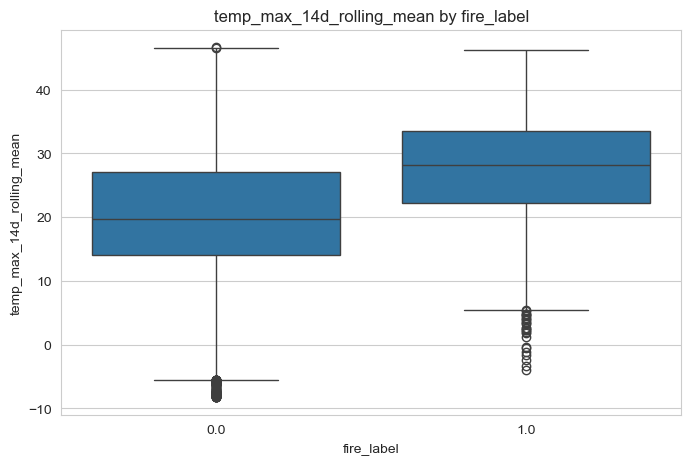

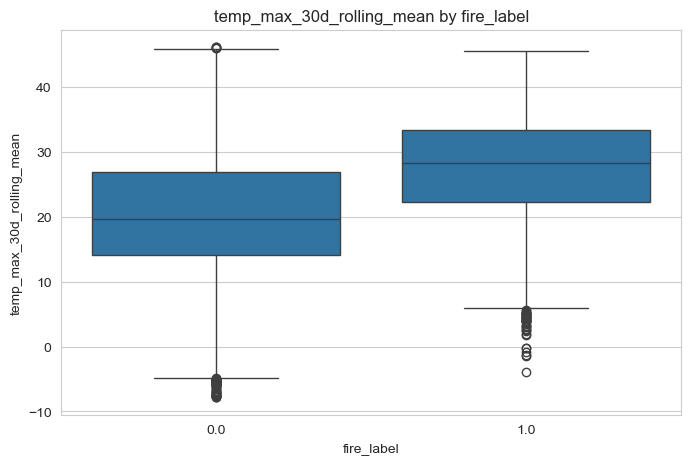

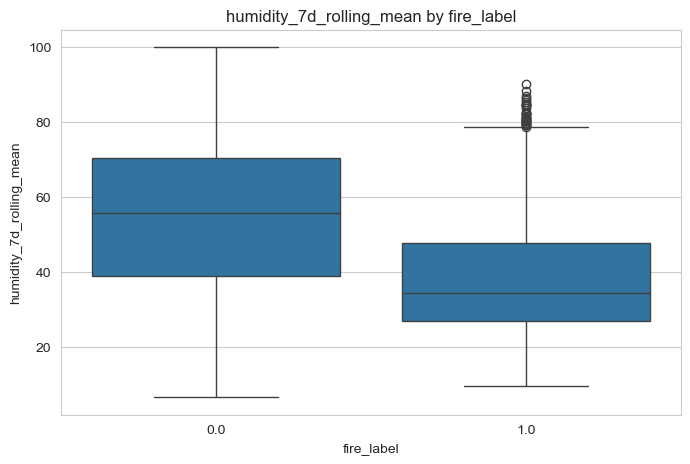

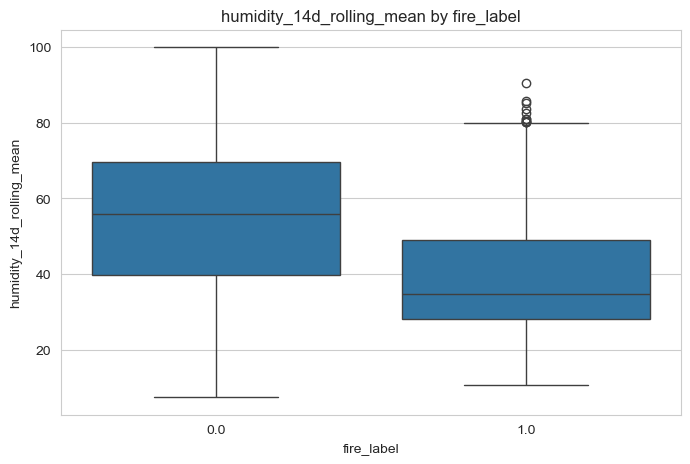

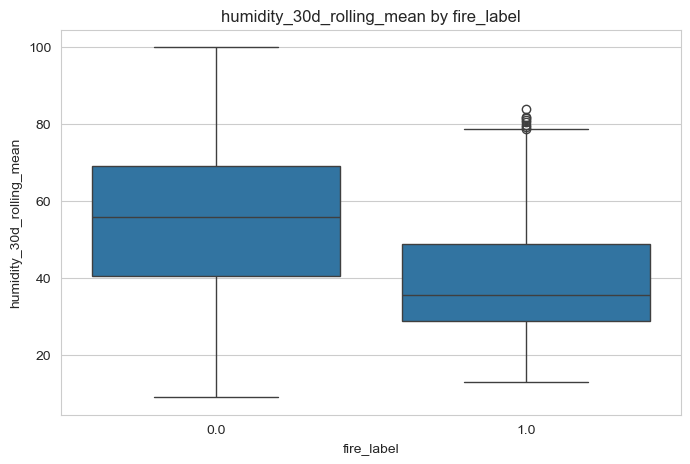

In [25]:
rolling_features = [
    "temp_max_7d_rolling_mean",
    "temp_max_14d_rolling_mean",
    "temp_max_30d_rolling_mean",
    "humidity_7d_rolling_mean",
    "humidity_14d_rolling_mean",
    "humidity_30d_rolling_mean"
]

for col in rolling_features:
    plt.figure(figsize=(8, 5))
    sns.boxplot(data=df, x="fire_label", y=col)
    plt.title(f"{col} by fire_label")
    plt.show()

- **temp_max_7d_rolling_mean:** Fire days have higher short-term average temperatures, indicating recent heat buildup contributes to fire risk.
- **temp_max_14d_rolling_mean:** Fire days show elevated 2-week temperature averages, suggesting sustained heat increases wildfire likelihood.
- **temp_max_30d_rolling_mean:** Fire days occur under consistently higher long-term temperatures, highlighting prolonged heat as a key factor.
- **humidity_7d_rolling_mean:** Fire days have lower short-term humidity, indicating recent dry conditions promote fires.
- **humidity_14d_rolling_mean:** Fire days are associated with lower 2-week humidity levels, reinforcing the role of sustained dryness.
- **humidity_30d_rolling_mean:** Fire days show consistently lower long-term humidity, confirming prolonged dry conditions increase risk.

### Fire counts over time by month-year

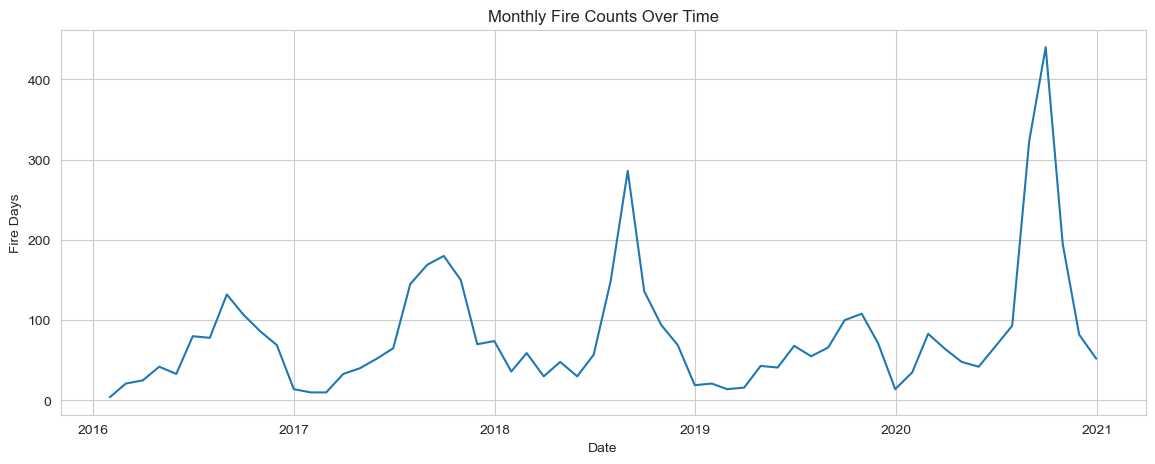

In [26]:
monthly_time = (
    df[df["fire_label"] == 1]
    .set_index("date")
    .resample("M")
    .size()
)

plt.figure(figsize=(14, 5))
sns.lineplot(x=monthly_time.index, y=monthly_time.values)
plt.title("Monthly Fire Counts Over Time")
plt.xlabel("Date")
plt.ylabel("Fire Days")
plt.show()

- Fire counts exhibit clear recurring seasonal patterns, with peaks consistently occurring during late summer months each year, reflecting the wildfire season.
- There is noticeable year-to-year variability, with some years (especially 2018 and 2020) showing significantly higher spikes, indicating more severe fire activity.
- The sharp surge in 2020 represents the highest peak, suggesting an extreme wildfire year compared to previous periods.
- Overall, the trend suggests that both seasonality and long-term environmental factors influence wildfire frequency over time.

### County-level fire rate

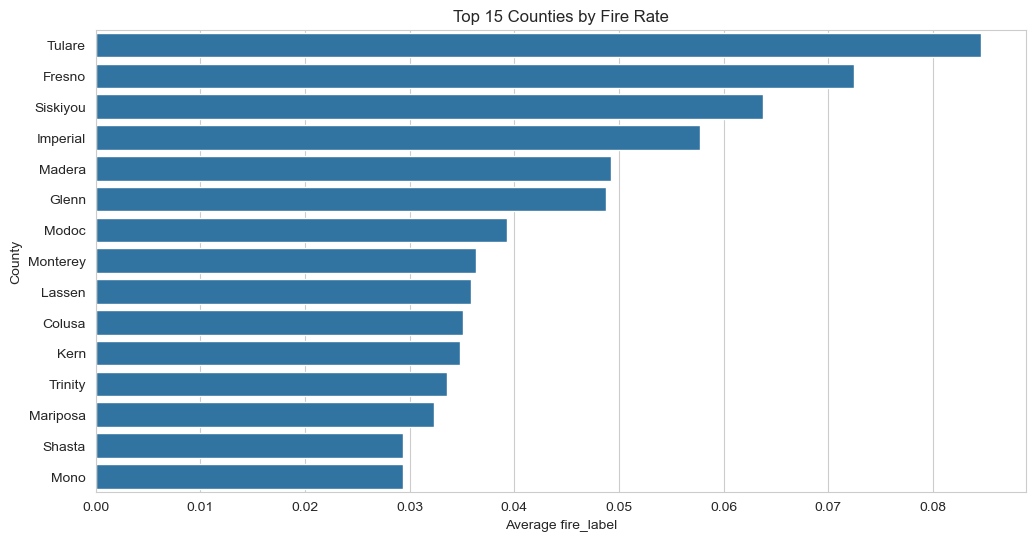

county
Tulare      0.084619
Fresno      0.072424
Siskiyou    0.063713
Imperial    0.057740
Madera      0.049278
Glenn       0.048780
Modoc       0.039323
Monterey    0.036336
Lassen      0.035839
Colusa      0.035092
Kern        0.034843
Trinity     0.033599
Mariposa    0.032354
Shasta      0.029368
Mono        0.029368
Name: fire_label, dtype: float64

In [27]:
county_fire_rate = (
    df.groupby("county")["fire_label"]
    .mean()
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(12, 6))
sns.barplot(x=county_fire_rate.values, y=county_fire_rate.index)
plt.title("Top 15 Counties by Fire Rate")
plt.xlabel("Average fire_label")
plt.ylabel("County")
plt.show()

display(county_fire_rate)

- Fire risk varies significantly by location, with Tulare (~8.5%) and Fresno (~7.2%) having the highest fire rates among all counties.
- Several counties such as Siskiyou and Imperial also show elevated fire rates, indicating consistent wildfire exposure in specific regions.
- Even among the top 15 counties, fire rates remain relatively low overall (mostly 3–8%), reflecting the rarity of fire events.
- This highlights that geographic location (county) is an important predictive feature, as some regions are consistently more prone to wildfires than others.

### Pairplot for selected features

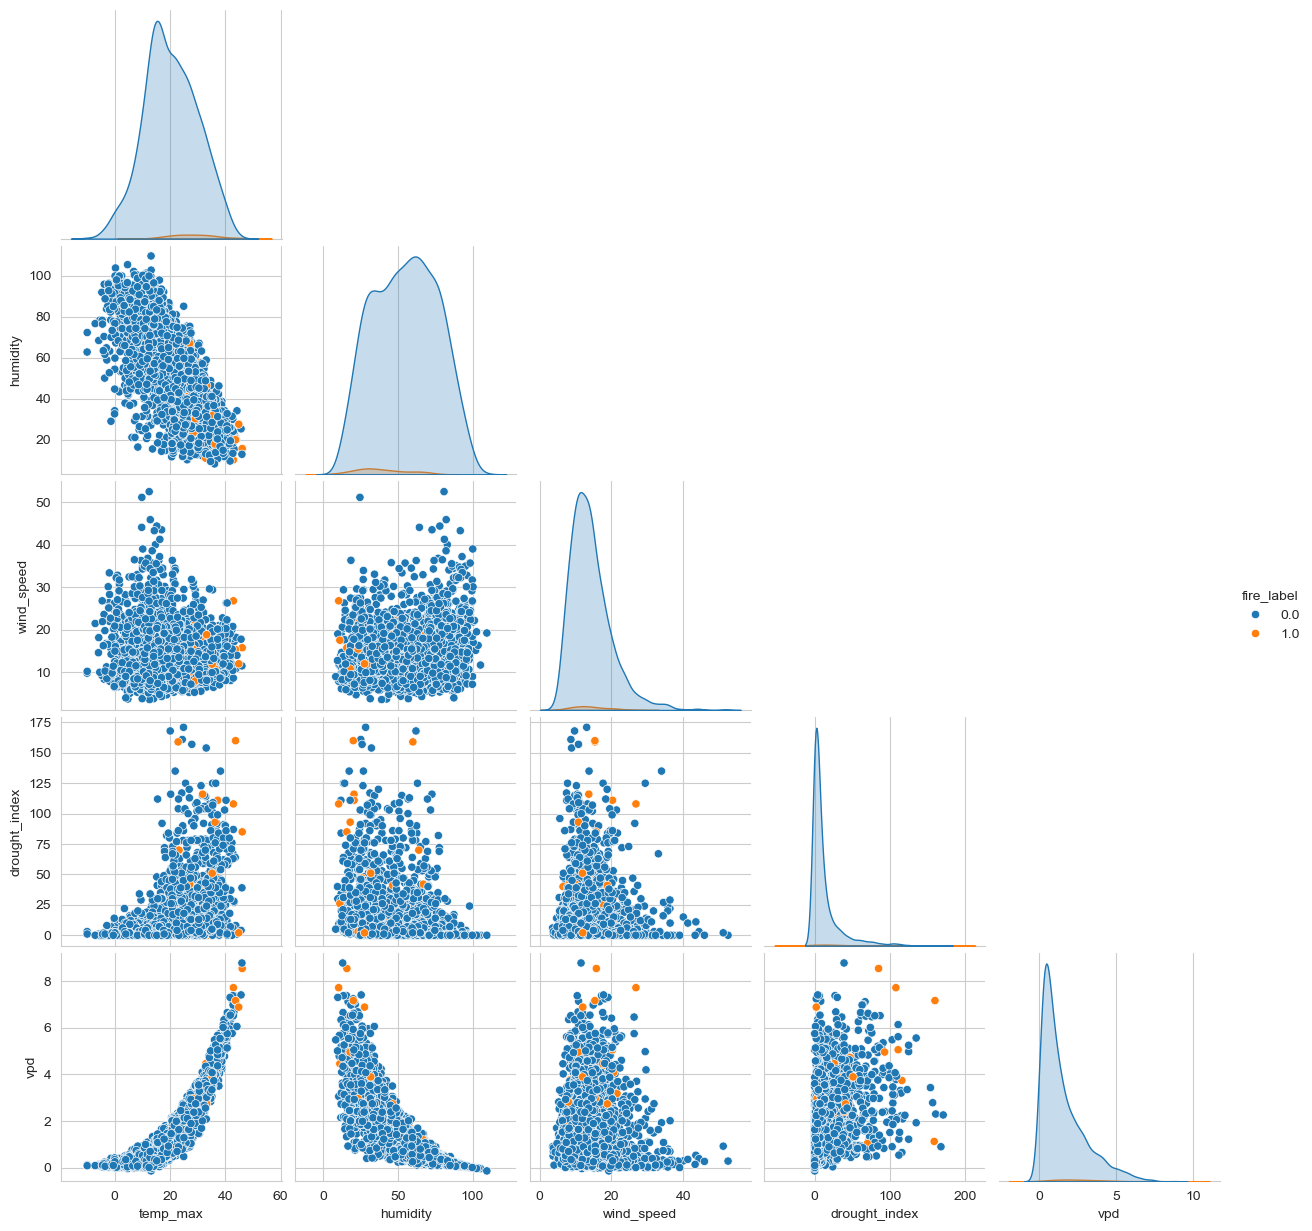

In [28]:
sample_df = df[["fire_label", "temp_max", "humidity", "wind_speed", "drought_index", "vpd"]].dropna()
sample_df = sample_df.sample(min(3000, len(sample_df)), random_state=42)

sns.pairplot(sample_df, hue="fire_label", corner=True)
plt.show()

- There is a clear negative relationship between temperature and humidity, confirming that hotter conditions are typically drier.
- VPD shows a strong nonlinear increase with temperature and decreases with humidity, capturing combined dryness effects effectively.
- Fire days (orange points) are mostly concentrated in regions with high temperature, low humidity, and high VPD, reinforcing key wildfire conditions.
- Drought index shows wide variability, but fire events tend to occur more frequently at higher drought levels.
- Wind speed does not show strong separation between fire and non-fire days, suggesting it is a weaker standalone predictor.
- The diagonal distributions show that most features are skewed (especially drought_index and VPD), indicating the presence of outliers.
- There is noticeable overlap between classes across most features, meaning no single variable perfectly separates fire vs non-fire days.
- Overall, the pairplot suggests that combinations of features (especially temperature + humidity + VPD) are more useful than individual variables for predicting wildfire risk.

### Numeric columns with strongest correlation to target

Top correlations with fire_label:


max_brightness                   0.992539
max_frp                          0.401320
fire_count                       0.378740
year                             0.150383
temp_max_humidity_interaction    0.124660
humidity_14d_rolling_mean       -0.123436
humidity_30d_rolling_mean       -0.123176
humidity_7d_rolling_mean        -0.123032
vpd                              0.121006
humidity                        -0.115971
temp_max_30d_rolling_mean        0.115937
temp_max_14d_rolling_mean        0.113513
temp_max_7d_rolling_mean         0.111140
temp_max                         0.105303
drought_index                    0.094014
Name: fire_label, dtype: float64

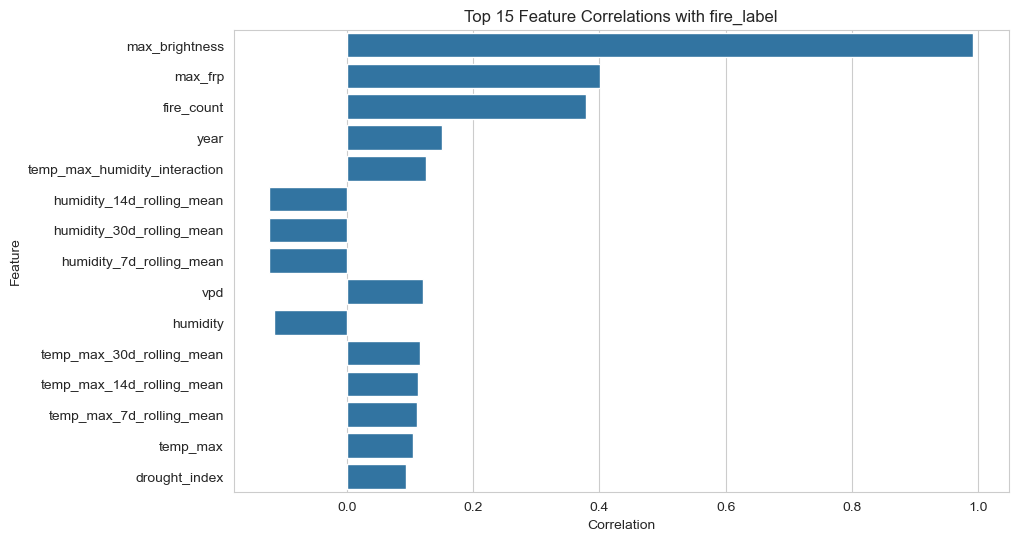

In [29]:
target_corr = (
    df.select_dtypes(include=[np.number])
      .corr()["fire_label"]
      .drop("fire_label")
      .sort_values(key=np.abs, ascending=False)
)

print("Top correlations with fire_label:")
display(target_corr.head(15))

plt.figure(figsize=(10, 6))
sns.barplot(x=target_corr.head(15).values, y=target_corr.head(15).index)
plt.title("Top 15 Feature Correlations with fire_label")
plt.xlabel("Correlation")
plt.ylabel("Feature")
plt.show()

- Fire-related variables (max_brightness, max_frp, fire_count) show the highest correlations, but they represent data leakage and should not be used for prediction.
- Among valid features, temperature-based features (temp_max and rolling means) show consistent positive correlation with fire occurrence.
- Humidity-related features (including rolling means) show negative correlation, confirming that lower humidity increases fire risk.
- Engineered features like VPD and interaction terms also show meaningful correlation, capturing combined environmental effects.
- The overall correlations are moderate rather than strong, indicating that wildfire prediction likely depends on multiple features working together rather than a single dominant variable.

### County Fire Map

In [30]:
import folium

# Aggregate fire counts by county
county_fire = (
    df[df["fire_label"] == 1]
    .groupby("county")
    .size()
    .reset_index(name="fire_days")
)

# Create base map (California center)
m = folium.Map(location=[37.5, -119.5], zoom_start=6)

# Add markers (approximate — not exact boundaries)
for _, row in county_fire.iterrows():
    folium.Marker(
        location=[37.5, -119.5],  # placeholder (no shapefile)
        popup=f"{row['county']}: {row['fire_days']}",
    ).add_to(m)

m